In [ ]:
 # import libraries

!pip install -q nltk scikit-learn pandas numpy matplotlib seaborn wordcloud

import os
import re
import string
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from scipy.sparse import hstack, csr_matrix

warnings.filterwarnings("ignore")

nltk.download("stopwords", quiet=True)
nltk.download("vader_lexicon", quiet=True)
nltk.download("punkt", quiet=True)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 12

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Environment ready. All libraries imported successfully.")


Environment ready. All libraries imported successfully.


In [ ]:
# dataset upload
TWEETS_PATH = "stock_tweets.csv"
YFINANCE_PATH = "stock_yfinance_data.csv"

def files_present():
    return os.path.exists(TWEETS_PATH) and os.path.exists(YFINANCE_PATH)

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if not files_present() and IN_COLAB:
    from google.colab import files
    print("Please upload 'stock_tweets.csv' and 'stock_yfinance_data.csv'.")
    uploaded = files.upload()
    for fname in uploaded.keys():
        if "tweet" in fname.lower():
            TWEETS_PATH = fname
        elif "yfinance" in fname.lower() or "yahoo" in fname.lower() or "stock" in fname.lower():
            YFINANCE_PATH = fname

if files_present():
    print(f"Found data files:\n  - {TWEETS_PATH}\n  - {YFINANCE_PATH}")
else:
    print("WARNING: Data files not found. Please ensure they are uploaded "
          "or present in the working directory before proceeding.")


Found data files:
  - stock_tweets.csv
  - stock_yfinance_data.csv


In [ ]:
# load dataset

def normalize_columns(df):
    '''Strip whitespace and standardize column names to avoid silent
    merge/key errors caused by formatting inconsistencies.'''
    df = df.copy()
    df.columns = [c.strip() for c in df.columns]
    return df

# Load tweets dataset..
tweets_df = pd.read_csv(TWEETS_PATH)
tweets_df = normalize_columns(tweets_df)

# Load stock price dataset..
stock_df = pd.read_csv(YFINANCE_PATH)
stock_df = normalize_columns(stock_df)

print("Tweets dataset loaded:", tweets_df.shape)
print("Stock price dataset loaded:", stock_df.shape)


Tweets dataset loaded: (80793, 4)
Stock price dataset loaded: (6300, 8)


In [ ]:
# clean and standardize column names

expected_tweets_cols = {
    "date": "Date",
    "tweet": "Tweet",
    "stock name": "Stock Name",
    "company name": "Company Name",
}

expected_stock_cols = {
    "date": "Date",
    "open": "Open",
    "high": "High",
    "low": "Low",
    "close": "Close",
    "adj close": "Adj Close",
    "volume": "Volume",
    "stock name": "Stock Name",
}

def standardize_schema(df, expected_map):
    rename_dict = {}
    for col in df.columns:
        key = col.strip().lower()
        if key in expected_map:
            rename_dict[col] = expected_map[key]
    return df.rename(columns=rename_dict)

tweets_df = standardize_schema(tweets_df, expected_tweets_cols)
stock_df = standardize_schema(stock_df, expected_stock_cols)
required_tweet_cols = {"Date", "Tweet", "Stock Name"}
required_stock_cols = {"Date", "Close", "Stock Name"}

missing_tweet_cols = required_tweet_cols - set(tweets_df.columns)
missing_stock_cols = required_stock_cols - set(stock_df.columns)

assert not missing_tweet_cols, f"Missing required columns in tweets_df: {missing_tweet_cols}"
assert not missing_stock_cols, f"Missing required columns in stock_df: {missing_stock_cols}"

print("Schema validated. Required columns are present in both datasets.")


Schema validated. Required columns are present in both datasets.


In [ ]:
# dataset overview
print("=" * 60)
print("TWEETS DATASET")
print("=" * 60)
print(f"Shape: {tweets_df.shape[0]} rows x {tweets_df.shape[1]} columns")
print(f"Columns: {list(tweets_df.columns)}")

print("\n" + "=" * 60)
print("STOCK PRICE (YFINANCE) DATASET")
print("=" * 60)
print(f"Shape: {stock_df.shape[0]} rows x {stock_df.shape[1]} columns")
print(f"Columns: {list(stock_df.columns)}")


TWEETS DATASET
Shape: 80793 rows x 4 columns
Columns: ['Date', 'Tweet', 'Stock Name', 'Company Name']

STOCK PRICE (YFINANCE) DATASET
Shape: 6300 rows x 8 columns
Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Stock Name']


In [ ]:
# dataset structure and sample data
print("Tweets dataset - data types:")
print(tweets_df.dtypes)
print("\nSample rows:")
display(tweets_df.head())

print("\nStock dataset - data types:")
print(stock_df.dtypes)
print("\nSample rows:")
display(stock_df.head())


Tweets dataset - data types:
Date            object
Tweet           object
Stock Name      object
Company Name    object
dtype: object

Sample rows:


,Date,Tweet,Stock Name,Company Name
0,2022-09-29 23:41:16+00:00,Mainstream media has done an amazing job at br...,TSLA,"Tesla, Inc."
1,2022-09-29 23:24:43+00:00,Tesla delivery estimates are at around 364k fr...,TSLA,"Tesla, Inc."
2,2022-09-29 23:18:08+00:00,3/ Even if I include 63.0M unvested RSUs as of...,TSLA,"Tesla, Inc."
3,2022-09-29 22:40:07+00:00,@RealDanODowd @WholeMarsBlog @Tesla Hahaha why...,TSLA,"Tesla, Inc."
4,2022-09-29 22:27:05+00:00,"@RealDanODowd @Tesla Stop trying to kill kids,...",TSLA,"Tesla, Inc."



Stock dataset - data types:
Date           object
Open          float64
High          float64
Low           float64
Close         float64
Adj Close     float64
Volume          int64
Stock Name     object
dtype: object

Sample rows:


,Date,Open,High,Low,Close,Adj Close,Volume,Stock Name
0,2021-09-30,260.333344,263.043335,258.333344,258.493347,258.493347,53868000,TSLA
1,2021-10-01,259.466675,260.260010,254.529999,258.406677,258.406677,51094200,TSLA
2,2021-10-04,265.500000,268.989990,258.706665,260.510010,260.510010,91449900,TSLA
3,2021-10-05,261.600006,265.769989,258.066681,260.196655,260.196655,55297800,TSLA
4,2021-10-06,258.733337,262.220001,257.739990,260.916656,260.916656,43898400,TSLA


In [ ]:
# checking missing values
print("Missing values in Tweets dataset:")
tweets_missing = tweets_df.isnull().sum()
tweets_missing_pct = (tweets_missing / len(tweets_df) * 100).round(2)
missing_summary_tweets = pd.DataFrame({
    "Missing Count": tweets_missing,
    "Missing %": tweets_missing_pct
})
display(missing_summary_tweets)

print("\nMissing values in Stock Price dataset:")
stock_missing = stock_df.isnull().sum()
stock_missing_pct = (stock_missing / len(stock_df) * 100).round(2)
missing_summary_stock = pd.DataFrame({
    "Missing Count": stock_missing,
    "Missing %": stock_missing_pct
})
display(missing_summary_stock)


Missing values in Tweets dataset:


,Missing Count,Missing %
Date,0,0.0
Tweet,0,0.0
Stock Name,0,0.0
Company Name,0,0.0



Missing values in Stock Price dataset:


,Missing Count,Missing %
Date,0,0.0
Open,0,0.0
High,0,0.0
Low,0,0.0
Close,0,0.0
Adj Close,0,0.0
Volume,0,0.0
Stock Name,0,0.0


In [ ]:
# handling missing values

before_tweets = len(tweets_df)
tweets_df = tweets_df.dropna(subset=["Tweet", "Stock Name", "Date"])
after_tweets = len(tweets_df)
print(f"Tweets dataset: dropped {before_tweets - after_tweets} rows with missing essential fields.")

before_stock = len(stock_df)
stock_df = stock_df.dropna(subset=["Close", "Stock Name", "Date"])
numeric_cols = [c for c in ["Open", "High", "Low", "Close", "Adj Close", "Volume"] if c in stock_df.columns]
stock_df[numeric_cols] = stock_df.groupby("Stock Name")[numeric_cols].ffill()
stock_df = stock_df.dropna(subset=numeric_cols)
after_stock = len(stock_df)
print(f"Stock dataset: dropped {before_stock - after_stock} rows with missing essential fields.")

print(f"\nFinal tweets dataset shape: {tweets_df.shape}")
print(f"Final stock dataset shape: {stock_df.shape}")


Tweets dataset: dropped 0 rows with missing essential fields.
Stock dataset: dropped 0 rows with missing essential fields.

Final tweets dataset shape: (80793, 4)
Final stock dataset shape: (6300, 8)


In [ ]:
# descriptive statistics and data insigths
print("Descriptive statistics - Stock Price dataset (numeric columns):")
display(stock_df[numeric_cols].describe().T)

print("\nNumber of unique stocks in tweets dataset:", tweets_df["Stock Name"].nunique())
print("Number of unique stocks in stock price dataset:", stock_df["Stock Name"].nunique())

print("\nTweet count per stock (Top 10):")
display(tweets_df["Stock Name"].value_counts().head(10))

print("\nTweet text length statistics (characters):")
tweet_len_stats = tweets_df["Tweet"].astype(str).str.len().describe()
display(tweet_len_stats)


Descriptive statistics - Stock Price dataset (numeric columns):


,count,mean,std,min,25%,50%,75%,max
Open,6300.0,1.747482e+02,1.349897e+02,11.0500,7.817000e+01,1.454751e+02,2.256650e+02,6.923500e+02
High,6300.0,1.775946e+02,1.367954e+02,11.2100,7.989100e+01,1.474750e+02,2.306625e+02,7.009900e+02
Low,6300.0,1.717347e+02,1.330500e+02,10.6100,7.679250e+01,1.435013e+02,2.214525e+02,6.860900e+02
Close,6300.0,1.746576e+02,1.349496e+02,11.0600,7.811000e+01,1.455050e+02,2.257850e+02,6.916900e+02
Adj Close,6300.0,1.737560e+02,1.345829e+02,10.8375,7.811000e+01,1.442481e+02,2.257850e+02,6.916900e+02
Volume,6300.0,2.906806e+07,3.342181e+07,307800.0000,5.857700e+06,1.518830e+07,4.122928e+07,3.116452e+08



Number of unique stocks in tweets dataset: 25
Number of unique stocks in stock price dataset: 25

Tweet count per stock (Top 10):


,count
Stock Name,
TSLA,37422
TSM,11034
AAPL,5056
AMZN,4089
MSFT,4089
PG,4089
NIO,3021
META,2751
AMD,2227



Tweet text length statistics (characters):


,Tweet
count,80793.000000
mean,165.164259
std,89.641189
min,4.000000
25%,84.000000
50%,152.000000
75%,258.000000
max,462.000000


In [ ]:
# data processing and alignment

tweets_df["Date"] = pd.to_datetime(tweets_df["Date"], utc=True, errors="coerce")
stock_df["Date"] = pd.to_datetime(stock_df["Date"], utc=True, errors="coerce")

tweets_df = tweets_df.dropna(subset=["Date"])
stock_df = stock_df.dropna(subset=["Date"])

tweets_df["Date_only"] = tweets_df["Date"].dt.tz_convert(None).dt.normalize()
stock_df["Date_only"] = stock_df["Date"].dt.tz_convert(None).dt.normalize()

print("Tweets date range: ", tweets_df["Date_only"].min(), "to", tweets_df["Date_only"].max())
print("Stock date range:  ", stock_df["Date_only"].min(), "to", stock_df["Date_only"].max())

overlap_start = max(tweets_df["Date_only"].min(), stock_df["Date_only"].min())
overlap_end = min(tweets_df["Date_only"].max(), stock_df["Date_only"].max())

if overlap_start <= overlap_end:
    print(f"\nDate ranges overlap from {overlap_start.date()} to {overlap_end.date()}. Safe to merge.")
else:
    print("\nWARNING: Date ranges do NOT overlap. Merge will likely fail or produce an empty dataset.")


Tweets date range:  2021-09-30 00:00:00 to 2022-09-29 00:00:00
Stock date range:   2021-09-30 00:00:00 to 2022-09-29 00:00:00

Date ranges overlap from 2021-09-30 to 2022-09-29. Safe to merge.


In [ ]:
# text preprocessing
stop_words = set(stopwords.words("english"))

URL_PATTERN = re.compile(r"https?://\S+|www\.\S+")
MENTION_PATTERN = re.compile(r"@\w+")
HASHTAG_SYMBOL_PATTERN = re.compile(r"#")
NON_ALPHA_PATTERN = re.compile(r"[^a-z\s]")
MULTI_SPACE_PATTERN = re.compile(r"\s+")

def clean_tweet(text):
    '''Apply a standard text-cleaning pipeline to a single tweet.

    Steps: lowercase -> remove URLs -> remove mentions -> remove hashtag
    symbols -> remove punctuation/digits -> remove stopwords -> collapse
    whitespace.
    '''
    if not isinstance(text, str):
        return ""

    # 1. Lowercase conversion
    text = text.lower()

    # 2. URL removal
    text = URL_PATTERN.sub(" ", text)

    # Remove user mentions (@username) - low semantic/sentiment value
    text = MENTION_PATTERN.sub(" ", text)

    # Remove hashtag symbol but keep the word itself (e.g., "#tesla" -> "tesla")
    text = HASHTAG_SYMBOL_PATTERN.sub("", text)

    # 3. Punctuation / non-alphabetic character removal
    text = NON_ALPHA_PATTERN.sub(" ", text)

    # 4. Stopword removal
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words and len(w) > 1]

    # 5. Whitespace cleanup
    cleaned = " ".join(tokens)
    cleaned = MULTI_SPACE_PATTERN.sub(" ", cleaned).strip()

    return cleaned

print("Cleaning tweet text... (this may take a moment for large datasets)")
tweets_df["Cleaned_Tweet"] = tweets_df["Tweet"].astype(str).apply(clean_tweet)

before_clean_drop = len(tweets_df)
tweets_df = tweets_df[tweets_df["Cleaned_Tweet"].str.len() > 0].reset_index(drop=True)
after_clean_drop = len(tweets_df)
print(f"Dropped {before_clean_drop - after_clean_drop} tweets that were empty after cleaning.")

print("\nExample of raw vs. cleaned tweets:")
display(tweets_df[["Tweet", "Cleaned_Tweet"]].head(5))


Cleaning tweet text... (this may take a moment for large datasets)
Dropped 64 tweets that were empty after cleaning.

Example of raw vs. cleaned tweets:


,Tweet,Cleaned_Tweet
0,Mainstream media has done an amazing job at br...,mainstream media done amazing job brainwashing...
1,Tesla delivery estimates are at around 364k fr...,tesla delivery estimates around analysts tsla
2,3/ Even if I include 63.0M unvested RSUs as of...,even include unvested rsus additional equity n...
3,@RealDanODowd @WholeMarsBlog @Tesla Hahaha why...,hahaha still trying stop tesla fsd bro get shi...
4,"@RealDanODowd @Tesla Stop trying to kill kids,...",stop trying kill kids sad deranged old man


In [ ]:
# sentimental analysis using VADER
sid = SentimentIntensityAnalyzer()

def get_vader_scores(text):
    '''Return VADER polarity scores for a given text string.'''
    if not isinstance(text, str) or len(text.strip()) == 0:
        return {"neg": 0.0, "neu": 1.0, "pos": 0.0, "compound": 0.0}
    return sid.polarity_scores(text)

print("Running VADER sentiment analysis on all tweets...")
sentiment_scores = tweets_df["Tweet"].astype(str).apply(get_vader_scores)
sentiment_df = pd.DataFrame(list(sentiment_scores))

tweets_df["Sentiment_Negative"] = sentiment_df["neg"]
tweets_df["Sentiment_Neutral"] = sentiment_df["neu"]
tweets_df["Sentiment_Positive"] = sentiment_df["pos"]
tweets_df["Sentiment_Compound"] = sentiment_df["compound"]

def categorize_sentiment(compound):
    if compound >= 0.05:
        return "Positive"
    elif compound <= -0.05:
        return "Negative"
    else:
        return "Neutral"

tweets_df["Sentiment_Label"] = tweets_df["Sentiment_Compound"].apply(categorize_sentiment)

print("Sentiment analysis complete.")
display(tweets_df[["Tweet", "Sentiment_Positive", "Sentiment_Negative",
                    "Sentiment_Neutral", "Sentiment_Compound", "Sentiment_Label"]].head(5))


Running VADER sentiment analysis on all tweets...
Sentiment analysis complete.


,Tweet,Sentiment_Positive,Sentiment_Negative,Sentiment_Neutral,Sentiment_Compound,Sentiment_Label
0,Mainstream media has done an amazing job at br...,0.115,0.127,0.758,0.0772,Positive
1,Tesla delivery estimates are at around 364k fr...,0.000,0.000,1.000,0.0000,Neutral
2,3/ Even if I include 63.0M unvested RSUs as of...,0.049,0.000,0.951,0.2960,Positive
3,@RealDanODowd @WholeMarsBlog @Tesla Hahaha why...,0.137,0.273,0.590,-0.7568,Negative
4,"@RealDanODowd @Tesla Stop trying to kill kids,...",0.000,0.526,0.474,-0.8750,Negative


In [ ]:
# destribution of sentimental labels
print("Overall sentiment distribution across all tweets:")
sentiment_counts = tweets_df["Sentiment_Label"].value_counts()
sentiment_pct = (sentiment_counts / len(tweets_df) * 100).round(2)
display(pd.DataFrame({"Count": sentiment_counts, "Percentage": sentiment_pct}))


Overall sentiment distribution across all tweets:


,Count,Percentage
Sentiment_Label,,
Positive,39842,49.35
Neutral,24785,30.70
Negative,16102,19.95


In [ ]:
# daily sentiment aggregation
daily_sentiment = (
    tweets_df.groupby(["Stock Name", "Date_only"])
    .agg(
        Sentiment_Positive=("Sentiment_Positive", "mean"),
        Sentiment_Negative=("Sentiment_Negative", "mean"),
        Sentiment_Neutral=("Sentiment_Neutral", "mean"),
        Sentiment_Compound=("Sentiment_Compound", "mean"),
        Tweet_Count=("Tweet", "count"),
        Cleaned_Tweet_Combined=("Cleaned_Tweet", lambda x: " ".join(x)),
    )
    .reset_index()
)

print(f"Daily aggregated sentiment dataset shape: {daily_sentiment.shape}")
display(daily_sentiment.head())


Daily aggregated sentiment dataset shape: (5910, 8)


,Stock Name,Date_only,Sentiment_Positive,Sentiment_Negative,Sentiment_Neutral,Sentiment_Compound,Tweet_Count,Cleaned_Tweet_Combined
0,AAPL,2021-09-30,0.107429,0.051714,0.841000,0.098900,7,need shares aapl returns last years bitcoin bt...
1,AAPL,2021-10-01,0.108818,0.019364,0.871818,0.291891,11,results lottofriday aapl afrm chwy mrna mrna g...
2,AAPL,2021-10-02,0.048750,0.021500,0.929750,0.007525,4,current holdings since ppl asked gogo ntnx pd ...
3,AAPL,2021-10-03,0.170000,0.000000,0.830000,0.834400,1,biggest challenge getting active managers bm a...
4,AAPL,2021-10-04,0.045500,0.038300,0.916100,0.047410,10,fb aapl amzn msft googl apple stock falls corr...


In [ ]:
# data integration
merged_df = pd.merge(
    daily_sentiment,
    stock_df,
    left_on=["Stock Name", "Date_only"],
    right_on=["Stock Name", "Date_only"],
    how="inner",
)

print(f"Merged dataset shape: {merged_df.shape}")
display(merged_df.head())


Merged dataset shape: (4184, 15)


,Stock Name,Date_only,Sentiment_Positive,Sentiment_Negative,Sentiment_Neutral,Sentiment_Compound,Tweet_Count,Cleaned_Tweet_Combined,Date,Open,High,Low,Close,Adj Close,Volume
0,AAPL,2021-09-30,0.107429,0.051714,0.841000,0.098900,7,need shares aapl returns last years bitcoin bt...,2021-09-30 00:00:00+00:00,143.660004,144.380005,141.279999,141.500000,140.478485,89056700
1,AAPL,2021-10-01,0.108818,0.019364,0.871818,0.291891,11,results lottofriday aapl afrm chwy mrna mrna g...,2021-10-01 00:00:00+00:00,141.899994,142.919998,139.110001,142.649994,141.620163,94639600
2,AAPL,2021-10-04,0.045500,0.038300,0.916100,0.047410,10,fb aapl amzn msft googl apple stock falls corr...,2021-10-04 00:00:00+00:00,141.759995,142.210007,138.270004,139.139999,138.135513,98322000
3,AAPL,2021-10-05,0.031600,0.057200,0.911200,0.139060,5,watch today marketoutlook video mentioned spy ...,2021-10-05 00:00:00+00:00,139.490005,142.240005,139.360001,141.110001,140.091278,80861100
4,AAPL,2021-10-06,0.067100,0.012600,0.920300,0.190330,10,buying shib like buying aapl steve jobs even b...,2021-10-06 00:00:00+00:00,139.470001,142.149994,138.369995,142.000000,140.974869,83221100


In [ ]:
# merge validation

if merged_df.empty:
    print("ERROR: Merged dataset is EMPTY. Running diagnostics...\n")

    tweet_tickers = set(daily_sentiment["Stock Name"].unique())
    price_tickers = set(stock_df["Stock Name"].unique())
    common_tickers = tweet_tickers & price_tickers

    print(f"Tickers in tweet data:  {sorted(tweet_tickers)}")
    print(f"Tickers in price data:  {sorted(price_tickers)}")
    print(f"Common tickers:         {sorted(common_tickers)}")

    if not common_tickers:
        print("\n>>> ROOT CAUSE: No overlapping Stock Name values between datasets. "
              "Check for ticker formatting differences (e.g., 'TSLA' vs 'Tesla').")

    print(f"\nTweet sentiment date range: {daily_sentiment['Date_only'].min()} to "
          f"{daily_sentiment['Date_only'].max()}")
    print(f"Stock price date range:     {stock_df['Date_only'].min()} to "
          f"{stock_df['Date_only'].max()}")

    sample_tweet_dates = set(daily_sentiment["Date_only"].dt.date.unique()[:5])
    sample_price_dates = set(stock_df["Date_only"].dt.date.unique()[:5])
    print(f"\nSample tweet dates: {sample_tweet_dates}")
    print(f"Sample price dates: {sample_price_dates}")

    raise ValueError(
        "Merged dataset is empty. Please review the diagnostics above to identify "
        "the mismatch between the tweets and stock price datasets before continuing."
    )
else:
    print(f"Merge successful: {merged_df.shape[0]} rows produced.")
    print(f"Unique stocks represented in merged data: {merged_df['Stock Name'].nunique()}")
    print(f"Date range of merged data: {merged_df['Date_only'].min().date()} to "
          f"{merged_df['Date_only'].max().date()}")

    retention_rate = len(merged_df) / max(len(daily_sentiment), 1) * 100
    print(f"Row retention rate (merged / daily_sentiment): {retention_rate:.1f}%")
    if retention_rate < 10:
        print("WARNING: Less than 10% of daily sentiment rows matched a trading day. "
              "This is expected if tweets occur on non-trading days (weekends/holidays), "
              "but verify the result looks reasonable.")


Merge successful: 4184 rows produced.
Unique stocks represented in merged data: 25
Date range of merged data: 2021-09-30 to 2022-09-29
Row retention rate (merged / daily_sentiment): 70.8%


In [ ]:
# target variable creation

merged_df = merged_df.sort_values(["Stock Name", "Date_only"]).reset_index(drop=True)

# Next day's closing price computed within each stock group
merged_df["Next_Close"] = merged_df.groupby("Stock Name")["Close"].shift(-1)

# Target = 1 if next day's close > current close, else 0
merged_df["Target"] = (merged_df["Next_Close"] > merged_df["Close"]).astype(int)

# Drop rows where Next_Close is NaN
before_target_drop = len(merged_df)
merged_df = merged_df.dropna(subset=["Next_Close"]).reset_index(drop=True)
after_target_drop = len(merged_df)
print(f"Dropped {before_target_drop - after_target_drop} rows with undefined target "
      f"(last trading day per stock in the merged dataset).")
print(f"Final modeling dataset shape: {merged_df.shape}")
print("\nTarget class distribution:")
target_counts = merged_df["Target"].value_counts().sort_index()
target_pct = (target_counts / len(merged_df) * 100).round(2)
display(pd.DataFrame({
    "Target": ["Down/Flat (0)", "Up (1)"],
    "Count": target_counts.values,
    "Percentage": target_pct.values
}))


Dropped 25 rows with undefined target (last trading day per stock in the merged dataset).
Final modeling dataset shape: (4159, 17)

Target class distribution:


,Target,Count,Percentage
0,Down/Flat (0),2162,51.98
1,Up (1),1997,48.02


In [ ]:
# feature enginnering usinf TF-IDF

TFIDF_MAX_FEATURES = 500

tfidf_vectorizer = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES,
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2),
    stop_words="english",
)
text_corpus = merged_df["Cleaned_Tweet_Combined"].fillna("").astype(str)
text_corpus = text_corpus.replace("", "no_tweet_content")

tfidf_matrix = tfidf_vectorizer.fit_transform(text_corpus)
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Vocabulary size: {len(tfidf_vectorizer.vocabulary_)}")


TF-IDF matrix shape: (4159, 500)
Vocabulary size: 500


In [ ]:
# sentiment feature engineering

sentiment_feature_cols = [
    "Sentiment_Positive",
    "Sentiment_Negative",
    "Sentiment_Neutral",
    "Sentiment_Compound",
    "Tweet_Count",
]

sentiment_features = merged_df[sentiment_feature_cols].fillna(0).values

# Standardize sentiment features
scaler = StandardScaler()
sentiment_features_scaled = scaler.fit_transform(sentiment_features)

print(f"Sentiment feature matrix shape: {sentiment_features_scaled.shape}")
print(f"Sentiment features used: {sentiment_feature_cols}")


Sentiment feature matrix shape: (4159, 5)
Sentiment features used: ['Sentiment_Positive', 'Sentiment_Negative', 'Sentiment_Neutral', 'Sentiment_Compound', 'Tweet_Count']


In [ ]:
# final feature matrix construction

X = hstack([tfidf_matrix, csr_matrix(sentiment_features_scaled)]).tocsr()
y = merged_df["Target"].values

print(f"Final feature matrix X shape: {X.shape}")
print(f"Final target vector y shape: {y.shape}")


Final feature matrix X shape: (4159, 505)
Final target vector y shape: (4159,)


In [ ]:
# train-test-split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"\nTraining target distribution: {np.bincount(y_train)}")
print(f"Test target distribution:     {np.bincount(y_test)}")


Training set: 3327 samples
Test set:     832 samples

Training target distribution: [1729 1598]
Test target distribution:     [433 399]


In [ ]:
# Logistic Regression Model Training
log_reg_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    C=1.0,
    solver="liblinear",
)

log_reg_model.fit(X_train, y_train)

y_pred = log_reg_model.predict(X_test)
y_pred_proba = log_reg_model.predict_proba(X_test)[:, 1]

print("Logistic Regression model trained successfully.")


Logistic Regression model trained successfully.


In [ ]:
# Model Evaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("=" * 50)
print("MODEL EVALUATION METRICS")
print("=" * 50)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")


MODEL EVALUATION METRICS
Accuracy:  0.5457
Precision: 0.5246
Recall:    0.5614
F1 Score:  0.5424


In [ ]:
# Classification Report
print("Detailed Classification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=["Down/Flat (0)", "Up (1)"],
    zero_division=0,
))


Detailed Classification Report:
               precision    recall  f1-score   support

Down/Flat (0)       0.57      0.53      0.55       433
       Up (1)       0.52      0.56      0.54       399

     accuracy                           0.55       832
    macro avg       0.55      0.55      0.55       832
 weighted avg       0.55      0.55      0.55       832



In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Actual Down/Flat (0)", "Actual Up (1)"],
    columns=["Predicted Down/Flat (0)", "Predicted Up (1)"],
)
print("Confusion Matrix:")
display(cm_df)


Confusion Matrix:


,Predicted Down/Flat (0),Predicted Up (1)
Actual Down/Flat (0),230,203
Actual Up (1),175,224


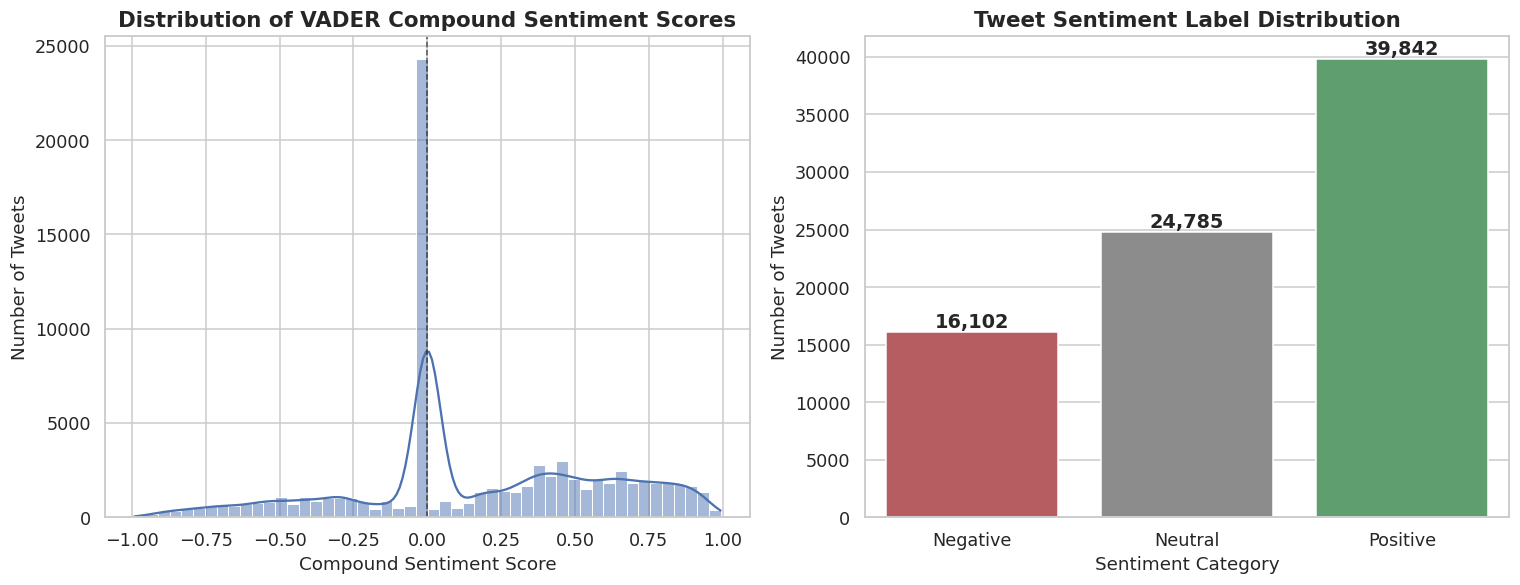

In [ ]:
# Sentiment Distribution Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.histplot(tweets_df["Sentiment_Compound"], bins=50, kde=True,
             color="#4C72B0", ax=axes[0])
axes[0].set_title("Distribution of VADER Compound Sentiment Scores")
axes[0].set_xlabel("Compound Sentiment Score")
axes[0].set_ylabel("Number of Tweets")
axes[0].axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.6)

sentiment_order = ["Negative", "Neutral", "Positive"]
sentiment_palette = {"Negative": "#C44E52", "Neutral": "#8C8C8C", "Positive": "#55A868"}
counts_ordered = tweets_df["Sentiment_Label"].value_counts().reindex(sentiment_order)
sns.barplot(
    x=counts_ordered.index, y=counts_ordered.values,
    palette=[sentiment_palette[s] for s in sentiment_order], ax=axes[1]
)
axes[1].set_title("Tweet Sentiment Label Distribution")
axes[1].set_xlabel("Sentiment Category")
axes[1].set_ylabel("Number of Tweets")
for i, v in enumerate(counts_ordered.values):
    axes[1].text(i, v + max(counts_ordered.values) * 0.01, f"{v:,}",
                 ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("sentiment_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


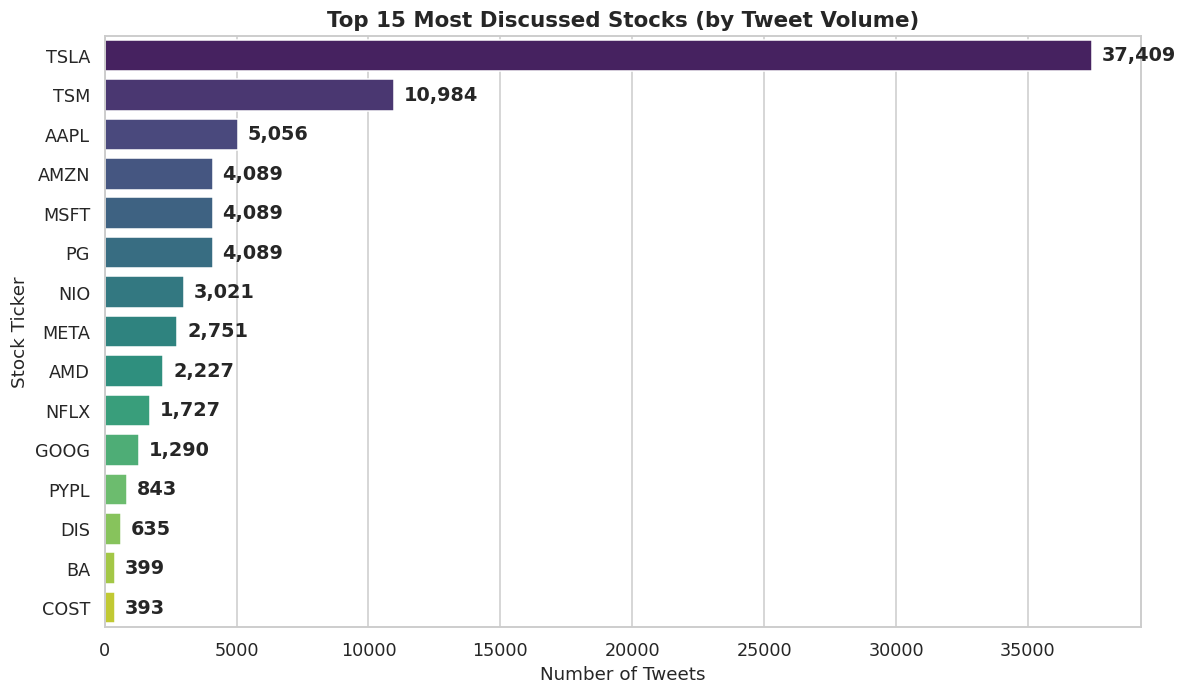

In [ ]:
# Most discussed stocks analysis
top_n = 15
top_stocks = tweets_df["Stock Name"].value_counts().head(top_n)

fig, ax = plt.subplots(figsize=(11, 6.5))
bars = sns.barplot(
    x=top_stocks.values, y=top_stocks.index,
    palette="viridis", ax=ax, orient="h"
)
ax.set_title(f"Top {top_n} Most Discussed Stocks (by Tweet Volume)")
ax.set_xlabel("Number of Tweets")
ax.set_ylabel("Stock Ticker")
for i, v in enumerate(top_stocks.values):
    ax.text(v + max(top_stocks.values) * 0.01, i, f"{v:,}", va="center", fontweight="bold")

plt.tight_layout()
plt.savefig("top_discussed_stocks.png", dpi=150, bbox_inches="tight")
plt.show()


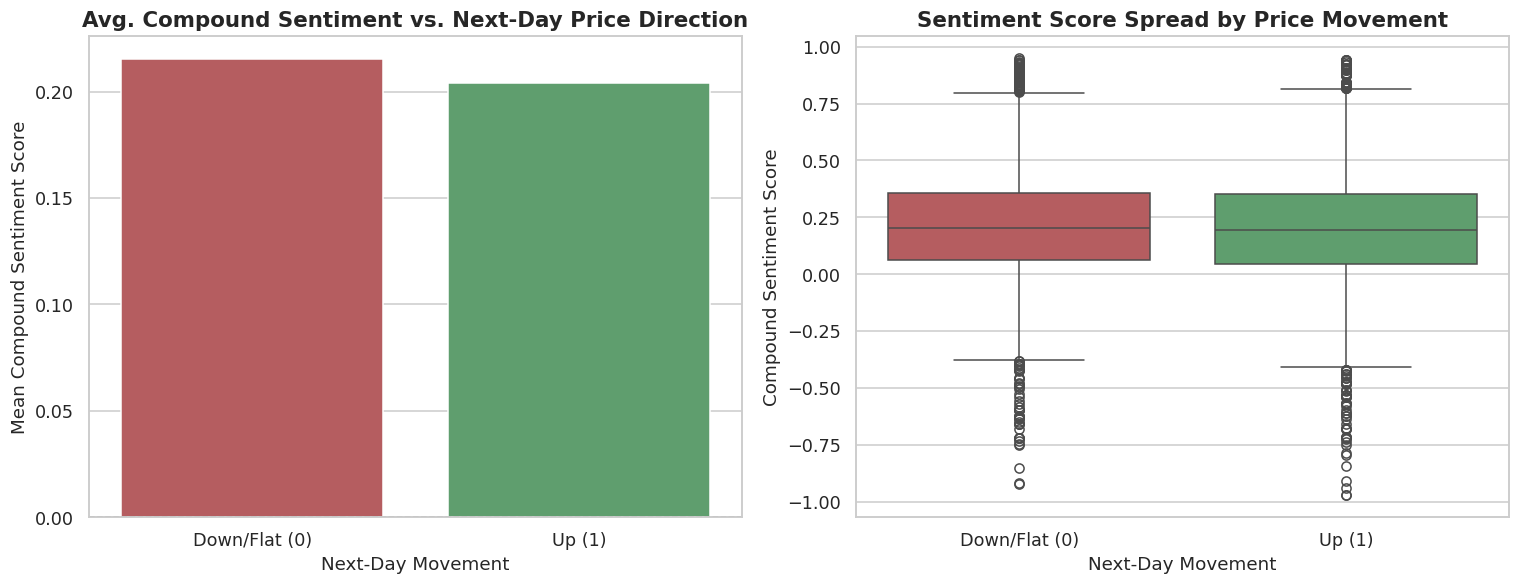

In [ ]:
# Sentiment and stock movement analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# a.Average compound sentiment by target outcome
sentiment_by_target = merged_df.groupby("Target")["Sentiment_Compound"].mean()
labels = ["Down/Flat (0)", "Up (1)"]
colors_target = ["#C44E52", "#55A868"]
sns.barplot(x=labels, y=sentiment_by_target.values, palette=colors_target, ax=axes[0])
axes[0].set_title("Avg. Compound Sentiment vs. Next-Day Price Direction")
axes[0].set_xlabel("Next-Day Movement")
axes[0].set_ylabel("Mean Compound Sentiment Score")
axes[0].axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.6)

# b.Boxplot showing sentiment score spread by target outcome
sns.boxplot(
    data=merged_df, x="Target", y="Sentiment_Compound",
    palette=colors_target, ax=axes[1]
)
axes[1].set_xticklabels(labels)
axes[1].set_title("Sentiment Score Spread by Price Movement")
axes[1].set_xlabel("Next-Day Movement")
axes[1].set_ylabel("Compound Sentiment Score")

plt.tight_layout()
plt.savefig("sentiment_vs_movement.png", dpi=150, bbox_inches="tight")
plt.show()


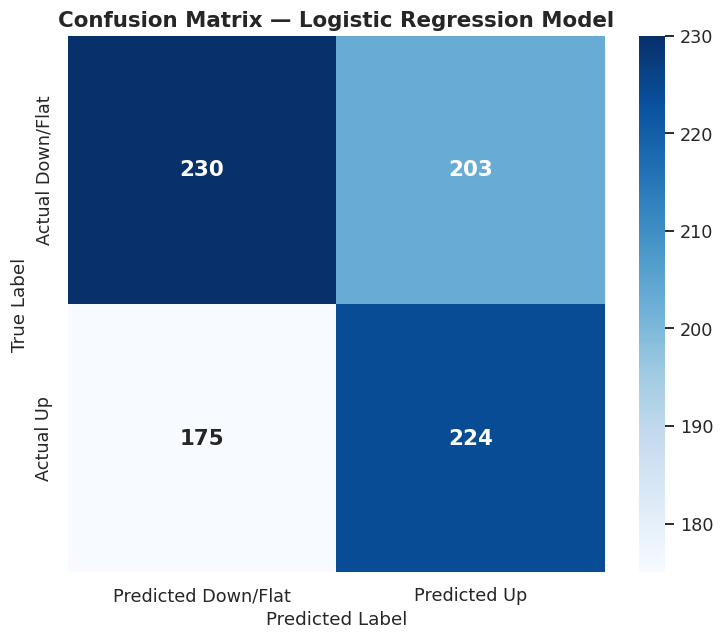

In [ ]:
# Confusion matrix heatmap
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", cbar=True,
    xticklabels=["Predicted Down/Flat", "Predicted Up"],
    yticklabels=["Actual Down/Flat", "Actual Up"],
    annot_kws={"size": 14, "weight": "bold"}, ax=ax
)
ax.set_title("Confusion Matrix — Logistic Regression Model")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

plt.tight_layout()
plt.savefig("confusion_matrix_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# Research Summary
print("=" * 65)
print(" FINAL RESEARCH SUMMARY")
print(" Predicting Stock Market Movements Using Social Media")
print(" Sentiment Analysis and Natural Language Processing")
print("=" * 65)

print("\n--- DATASET SIZES ---")
print(f"Raw tweets loaded:                 {tweets_df.shape[0]:,} rows")
print(f"Raw stock price records loaded:    {stock_df.shape[0]:,} rows")
print(f"Daily aggregated sentiment rows:   {daily_sentiment.shape[0]:,} rows")
print(f"Final merged modeling dataset:     {merged_df.shape[0]:,} rows")
print(f"Number of unique stocks modeled:   {merged_df['Stock Name'].nunique()}")
print(f"Training samples:                  {X_train.shape[0]:,}")
print(f"Test samples:                      {X_test.shape[0]:,}")
print(f"Total feature dimensions:          {X.shape[1]:,} "
      f"(TF-IDF: {tfidf_matrix.shape[1]}, Sentiment/Aux: {sentiment_features_scaled.shape[1]})")

print("\n--- FINAL MODEL PERFORMANCE (Logistic Regression) ---")
print(f"Accuracy:   {accuracy:.4f}  ({accuracy * 100:.2f}%)")
print(f"Precision:  {precision:.4f}  ({precision * 100:.2f}%)")
print(f"Recall:     {recall:.4f}  ({recall * 100:.2f}%)")
print(f"F1 Score:   {f1:.4f}  ({f1 * 100:.2f}%)")

print("\n" + "=" * 65)
print(" END OF RESEARCH NOTEBOOK")
print("=" * 65)


 FINAL RESEARCH SUMMARY
 Predicting Stock Market Movements Using Social Media
 Sentiment Analysis and Natural Language Processing

--- DATASET SIZES ---
Raw tweets loaded:                 80,729 rows
Raw stock price records loaded:    6,300 rows
Daily aggregated sentiment rows:   5,910 rows
Final merged modeling dataset:     4,159 rows
Number of unique stocks modeled:   25
Training samples:                  3,327
Test samples:                      832
Total feature dimensions:          505 (TF-IDF: 500, Sentiment/Aux: 5)

--- FINAL MODEL PERFORMANCE (Logistic Regression) ---
Accuracy:   0.5457  (54.57%)
Precision:  0.5246  (52.46%)
Recall:     0.5614  (56.14%)
F1 Score:   0.5424  (54.24%)

 END OF RESEARCH NOTEBOOK
